In [1]:
# Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
# Sample Kenyan county-level dataset
data = {
 "County": ["Nairobi", "Mombasa", "Kisumu", "Nakuru", "Uasin Gishu"],
 "Income": [150000, 120000, 90000, 95000, 100000], # Average monthly income (KES)
 "Education": [85, 78, 72, 75, 77], # % with secondary education
 "Water_Access": [90, 85, 70, 75, 80], # % access to clean water
 "Electricity": [95, 88, 65, 70, 75], # % electricity access
 "Urbanization": [100, 95, 60, 65, 70] # % urban population
}
# Create DataFrame
df = pd.DataFrame(data)
# Remove non-numeric column
df_numeric = df.drop(columns=["County"])

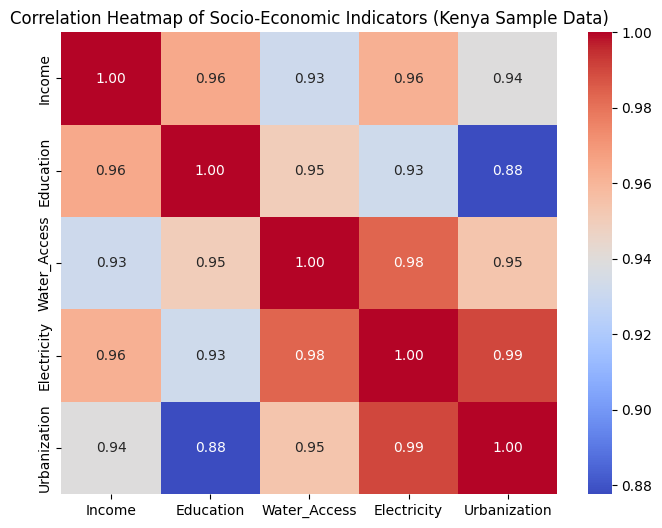

In [3]:
# Compute correlation matrix
corr_matrix = df_numeric.corr()
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
# Title
plt.title("Correlation Heatmap of Socio-Economic Indicators (Kenya Sample Data)")
# Show plot
plt.show()


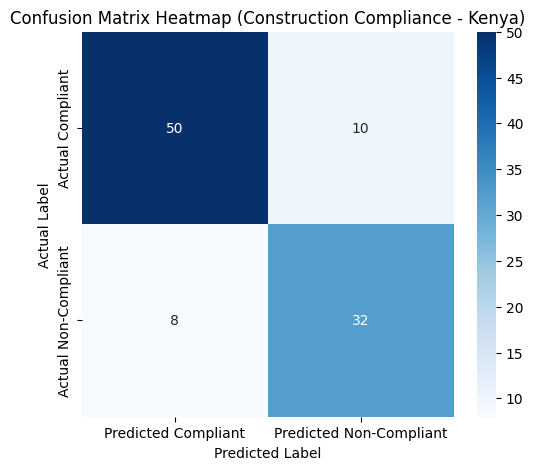

In [4]:
# Create confusion matrix data (Kenyan construction inspection context)
data = [[50, 10],
 [8, 32]]
# Create DataFrame
conf_matrix = pd.DataFrame(data,
 index=["Actual Compliant", "Actual Non-Compliant"],
 columns=["Predicted Compliant", "Predicted Non-Compliant"])
# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
# Titles and labels
plt.title("Confusion Matrix Heatmap (Construction Compliance - Kenya)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
# Show plot
plt.show()

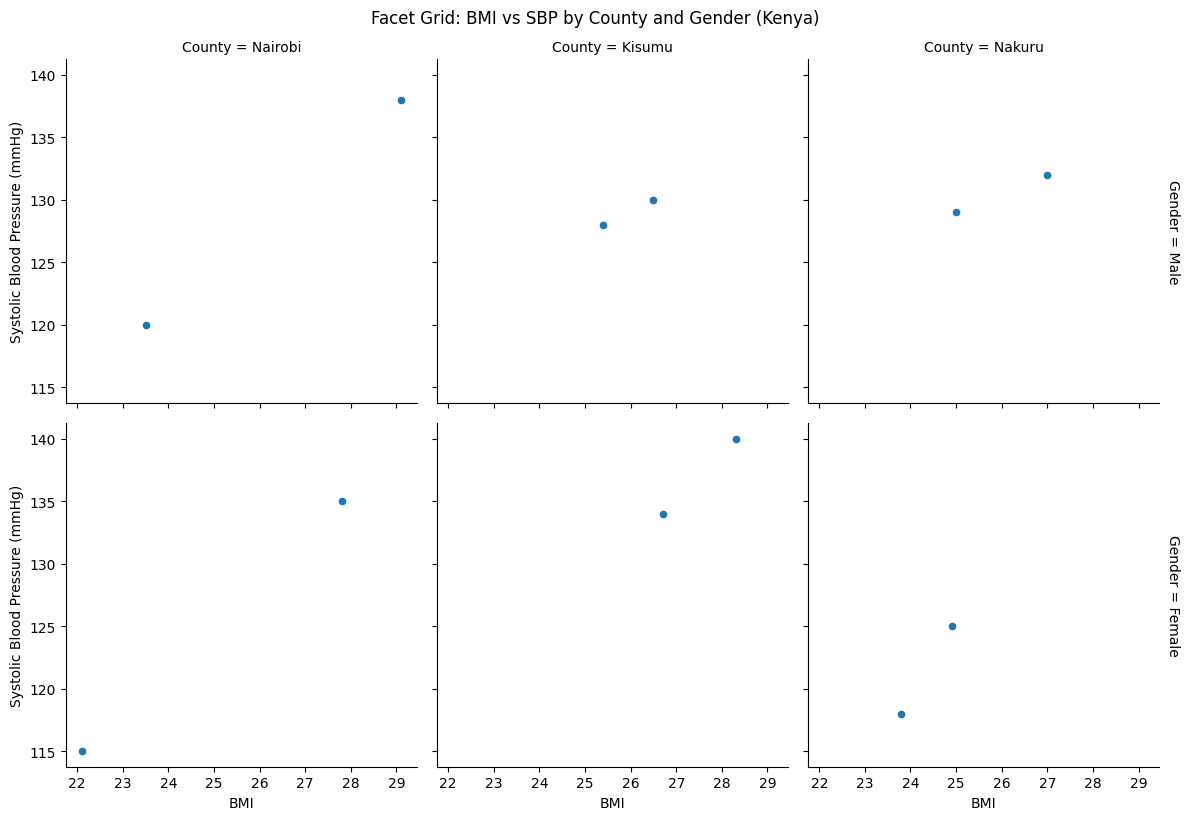

In [5]:
# Sample Kenyan healthcare dataset
data = {
 "County": ["Nairobi","Nairobi","Nairobi","Kisumu","Kisumu","Kisumu",
 "Nakuru","Nakuru","Nakuru","Nairobi","Kisumu","Nakuru"],
 "Gender": ["Male","Female","Female","Male","Female","Male",
 "Female","Male","Female","Male","Female","Male"],
 "BMI": [23.5, 27.8, 22.1, 25.4, 28.3, 26.5, 24.9, 27.0, 23.8, 29.1, 26.7, 25.0],
 "SBP": [120, 135, 115, 128, 140, 130, 125, 132, 118, 138, 134, 129] # Systolic BP
}
# Create DataFrame
df = pd.DataFrame(data)
# Create Facet Grid
g = sns.FacetGrid(df, col="County", row="Gender", height=4, margin_titles=True)
g.map(sns.scatterplot, "BMI", "SBP")
# Axis labels and title
g.set_axis_labels("BMI", "Systolic Blood Pressure (mmHg)")
g.fig.suptitle("Facet Grid: BMI vs SBP by County and Gender (Kenya)", y=1.02)
# Show plot
plt.show()

Text(0.5, 1.05, 'Small Multiples: Monthly Rainfall by County (Kenya)')

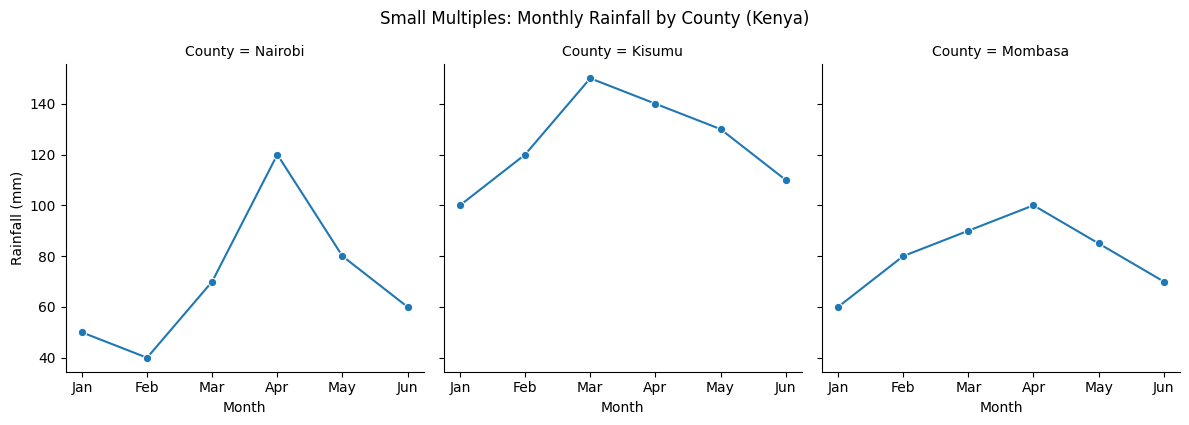

In [6]:
# Sample Kenyan rainfall dataset
data = {
 "Month": ["Jan","Feb","Mar","Apr","May","Jun"]*3,
 "County": ["Nairobi"]*6 + ["Kisumu"]*6 + ["Mombasa"]*6,
 "Rainfall": [50, 40, 70, 120, 80, 60, # Nairobi
 100, 120, 150, 140, 130, 110, # Kisumu
 60, 80, 90, 100, 85, 70] # Mombasa
}
# Create DataFrame
df = pd.DataFrame(data)
# Create Small Multiples using FacetGrid
g = sns.FacetGrid(df, col="County", height=4, sharey=True)
g.map(sns.lineplot, "Month", "Rainfall", marker="o")
# Add axis labels and title
g.set_axis_labels("Month", "Rainfall (mm)")
g.fig.suptitle("Small Multiples: Monthly Rainfall by County (Kenya)", y=1.05)
# Show plot

In [10]:
import plotly.express as px
import pandas as pd
# Sample data (Kenyan context)
data = {
 "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"] * 3,
 "City": ["Nairobi"]*6 + ["Mombasa"]*6 + ["Kisumu"]*6,
 "Rainfall_mm": [80, 60, 90, 120, 100, 70, # Nairobi
 150, 120, 130, 160, 140, 110, # Mombasa
 100, 90, 110, 140, 130, 95] # Kisumu
 }
# Create DataFrame
df = pd.DataFrame(data)
# Create interactive line chart
fig = px.line(df, x="Month", y="Rainfall_mm", color="City",
 title="Monthly Rainfall in Kenyan Cities (Jan-Jun 2026)",
 markers=True, # Show data points
 hover_data={"Rainfall_mm": True, "City": True, "Month": True})
# Enable interactive features
fig.update_layout(
 xaxis_title="Month",
 yaxis_title="Rainfall (mm)",
 hovermode="x unified" # Show all city values for a month on hover
)
# Show the interactive chart
fig.show()

In [11]:
# Import required libraries
import networkx as nx
import plotly.graph_objects as go
# Create a graph
G = nx.Graph()
# Add nodes (Kenyan cities)
cities = ["Nairobi", "Mombasa", "Kisumu", "Eldoret", "Nakuru"]
G.add_nodes_from(cities)
# Add edges (connections between hubs)
connections = [("Nairobi", "Mombasa"),
 ("Nairobi", "Kisumu"),
 ("Nairobi", "Eldoret"),
 ("Kisumu", "Nakuru"),
 ("Eldoret", "Nakuru"),
 ("Mombasa", "Nairobi")]
G.add_edges_from(connections)
# Get positions for visualization (spring layout for topological view)
pos = nx.spring_layout(G, seed=42) # Not geographic, emphasizes connectivity
# Extract edge coordinates for Plotly
edge_x = []
edge_y = []
for edge in G.edges():
 x0, y0 = pos[edge[0]]
 x1, y1 = pos[edge[1]]
 edge_x += [x0, x1, None]
 edge_y += [y0, y1, None]
# Extract node coordinates
node_x = [pos[node][0] for node in G.nodes()]
node_y = [pos[node][1] for node in G.nodes()]
# Create Plotly figure
fig = go.Figure()
13# Add edges
fig.add_trace(go.Scatter(x=edge_x, y=edge_y,
 line=dict(width=2, color='gray'),
 hoverinfo='none',
 mode='lines'))
# Add nodes
fig.add_trace(go.Scatter(x=node_x, y=node_y,
 mode='markers+text',
 marker=dict(size=20, color='skyblue'),
 text=list(G.nodes()),
 textposition="bottom center",
 hoverinfo='text'))
# Update layout
fig.update_layout(title="Topological Network of Kenyan Logistics Hubs",
 showlegend=False,
 xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
 yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
# Show intera

In [14]:
 !pip install anytree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 2.6 MB/s eta 0:00:00


In [15]:
from anytree import Node, RenderTree
# Create tree nodes
principal = Node("Principal")
# Heads of Departments (HODs)
hod_science = Node("HOD Science", parent=principal)
hod_math = Node("HOD Mathematics", parent=principal)
hod_english = Node("HOD English", parent=principal)
# Teachers under each HOD
Node("Biology Teacher", parent=hod_science)
Node("Chemistry Teacher", parent=hod_science)
Node("Physics Teacher", parent=hod_science)
Node("Algebra Teacher", parent=hod_math)
Node("Geometry Teacher", parent=hod_math)
Node("English Literature Teacher", parent=hod_english)
Node("Grammar Teacher", parent=hod_english)
# Display the tree structure
for pre, fill, node in RenderTree(principal):
 print(f"{pre}{node.name}")

Principal
├── HOD Science
│   ├── Biology Teacher
│   ├── Chemistry Teacher
│   └── Physics Teacher
├── HOD Mathematics
│   ├── Algebra Teacher
│   └── Geometry Teacher
└── HOD English
    ├── English Literature Teacher
    └── Grammar Teacher
